# Vergleichende Analyse des Token-Längen-Experiments (Translation: SFT vs. DPO)
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook analysiert und visualisiert den Einfluss unterschiedlicher maximaler Token-Sequenzlängen (**256**, **500**, **1000**) auf:
1. **SFT Fine-Tuning (mBART-50 256 vs. 500 vs. 1000 Tokens)**
2. **DPO Alignment (Direct Preference Optimization 256 vs. 500 vs. 1000 Tokens)**

Untersuchte Dimensionen:
- **Übersetzungsqualität & Stil:** Simplicity-Score ($R_{style}$), Semantische Erhaltung zu AS ($R_{sem, AS}$), Ähnlichkeit zur Referenz ($Sim_{ref}$) und Composite Reward.
- **Textkürzung & Truncation:** Satzabbrüche, Wortlänge und Kompressionsrate.
- **Lexikalische Metriken:** BLEU, ROUGE-1, ROUGE-2 und ROUGE-L.
- **Stratifizierung nach Eingabelängen:** Performance auf kurzen (< 200), mittleren (200-450) und langen (> 450) Quelltexten.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.size"] = 11
plt.rcParams["figure.titlesize"] = 14

SUMMARY_CSV = "../../../results/evaluation/token_length_comparison_summary.csv"
DETAILS_CSV = "../../../results/evaluation/token_length_comparison_detailed.csv"

# Fallback paths if executed from project root
if not os.path.exists(SUMMARY_CSV):
    SUMMARY_CSV = "results/evaluation/token_length_comparison_summary.csv"
    DETAILS_CSV = "results/evaluation/token_length_comparison_detailed.csv"

## 1. Übersichtstabelle der aggregierten Evaluationsergebnisse (SFT & DPO)

In [2]:
if os.path.exists(SUMMARY_CSV):
    df_summary = pd.read_csv(SUMMARY_CSV)
    display(df_summary)
else:
    print(f"Evaluationsdatei {SUMMARY_CSV} nicht gefunden. Bitte zuerst das Evaluationsskript ausführen.")

,model,max_len,r_style_mean,r_sem_as_mean,sim_ref_mean,composite_reward_mean,bleu_mean,rouge1_f1_mean,rouge2_f1_mean,rougeL_f1_mean,avg_gen_tokens,compression_ratio_mean,truncation_rate
0,sft_len256,256,0.608555,0.889153,0.864867,0.748854,0.008910,0.230408,0.076599,0.129238,154.648649,0.358877,0.432432
1,sft_len500,500,0.658343,0.853308,0.851959,0.755825,0.019827,0.287022,0.100736,0.149256,237.594595,0.498396,0.432432
2,sft_len1000,1000,0.580443,0.874746,0.862582,0.727594,0.024900,0.300781,0.109011,0.160576,288.864865,0.577454,0.189189
3,dpo_len256,256,0.439102,0.897759,0.835337,0.668431,0.000002,0.055212,0.020447,0.041112,37.783784,0.074062,0.405405
4,dpo_len500,500,0.417475,0.883972,0.823307,0.650724,0.000926,0.059979,0.020783,0.042162,43.216216,0.086694,0.297297
5,dpo_len1000,1000,0.337639,0.894886,0.827706,0.616263,0.002409,0.099390,0.031207,0.065144,114.081081,0.156034,0.108108


## 2. Kernmetriken im Vergleich (Style, Semantik & Composite Reward)

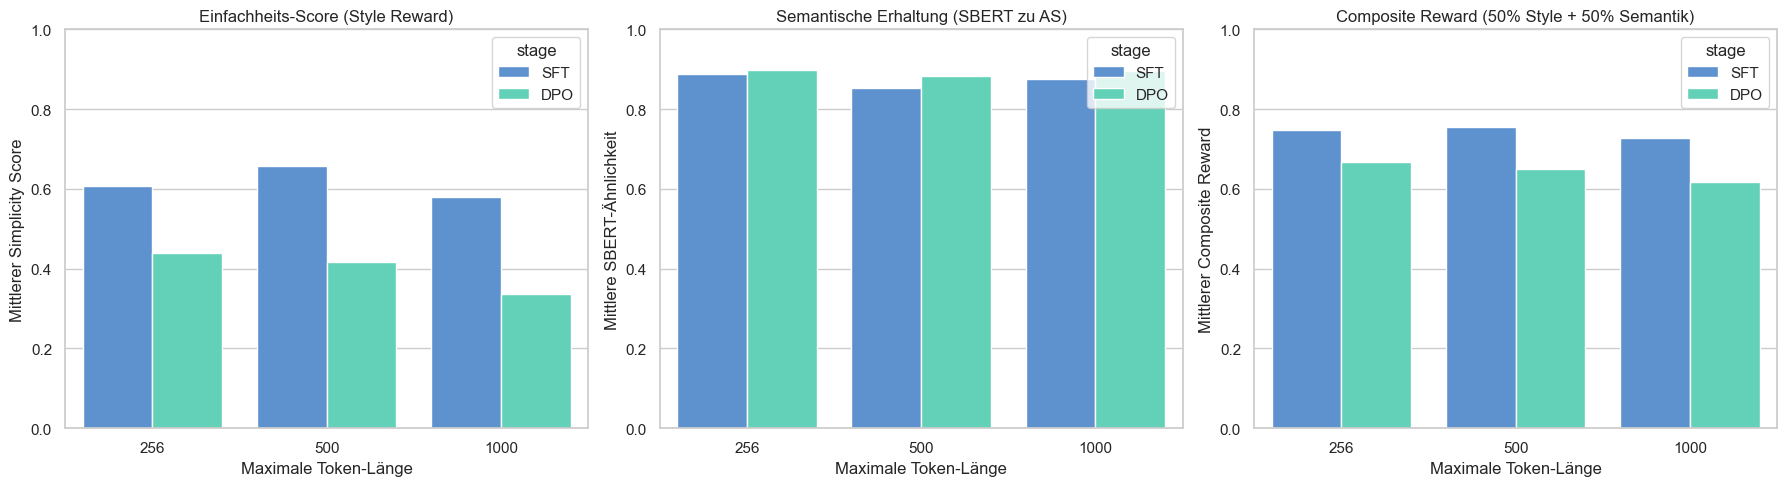

In [3]:
if os.path.exists(SUMMARY_CSV):
    df_summary['stage'] = df_summary['model'].apply(lambda x: 'SFT' if 'sft' in x else 'DPO')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Style Simplicity Score
    sns.barplot(data=df_summary, x='max_len', y='r_style_mean', hue='stage', ax=axes[0], palette=['#4A90E2', '#50E3C2'])
    axes[0].set_title("Einfachheits-Score (Style Reward)")
    axes[0].set_xlabel("Maximale Token-Länge")
    axes[0].set_ylabel("Mittlerer Simplicity Score")
    axes[0].set_ylim(0, 1.0)

    # 2. Semantic Preservation to AS
    sns.barplot(data=df_summary, x='max_len', y='r_sem_as_mean', hue='stage', ax=axes[1], palette=['#4A90E2', '#50E3C2'])
    axes[1].set_title("Semantische Erhaltung (SBERT zu AS)")
    axes[1].set_xlabel("Maximale Token-Länge")
    axes[1].set_ylabel("Mittlere SBERT-Ähnlichkeit")
    axes[1].set_ylim(0, 1.0)

    # 3. Composite Reward
    sns.barplot(data=df_summary, x='max_len', y='composite_reward_mean', hue='stage', ax=axes[2], palette=['#4A90E2', '#50E3C2'])
    axes[2].set_title("Composite Reward (50% Style + 50% Semantik)")
    axes[2].set_xlabel("Maximale Token-Länge")
    axes[2].set_ylabel("Mittlerer Composite Reward")
    axes[2].set_ylim(0, 1.0)

    plt.tight_layout()
    plt.show()

## 3. Längen- und Truncation-Analyse (Kürzungsrate vs. Satzabbrüche)

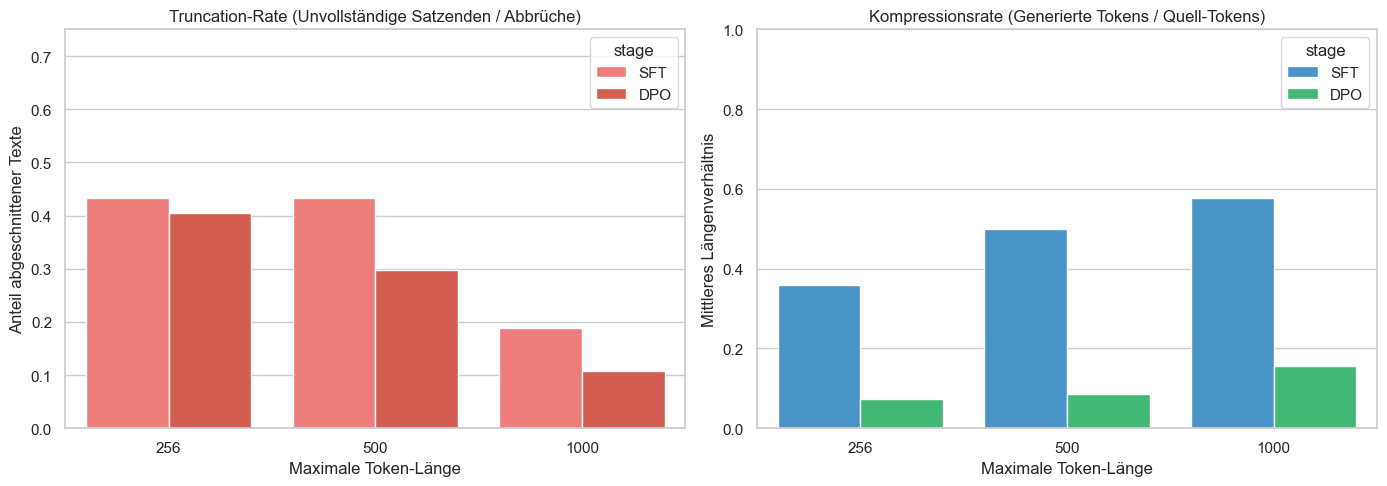

In [4]:
if os.path.exists(SUMMARY_CSV):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Truncation Rate
    sns.barplot(data=df_summary, x='max_len', y='truncation_rate', hue='stage', ax=axes[0], palette=['#FF6B6B', '#E74C3C'])
    axes[0].set_title("Truncation-Rate (Unvollständige Satzenden / Abbrüche)")
    axes[0].set_xlabel("Maximale Token-Länge")
    axes[0].set_ylabel("Anteil abgeschnittener Texte")
    axes[0].set_ylim(0, 0.75)

    # 2. Compression Ratio
    sns.barplot(data=df_summary, x='max_len', y='compression_ratio_mean', hue='stage', ax=axes[1], palette=['#3498DB', '#2ECC71'])
    axes[1].set_title("Kompressionsrate (Generierte Tokens / Quell-Tokens)")
    axes[1].set_xlabel("Maximale Token-Länge")
    axes[1].set_ylabel("Mittleres Längenverhältnis")
    axes[1].set_ylim(0, 1.0)

    plt.tight_layout()
    plt.show()

## 4. Lexikalische Überlappungs-Metriken (BLEU & ROUGE)

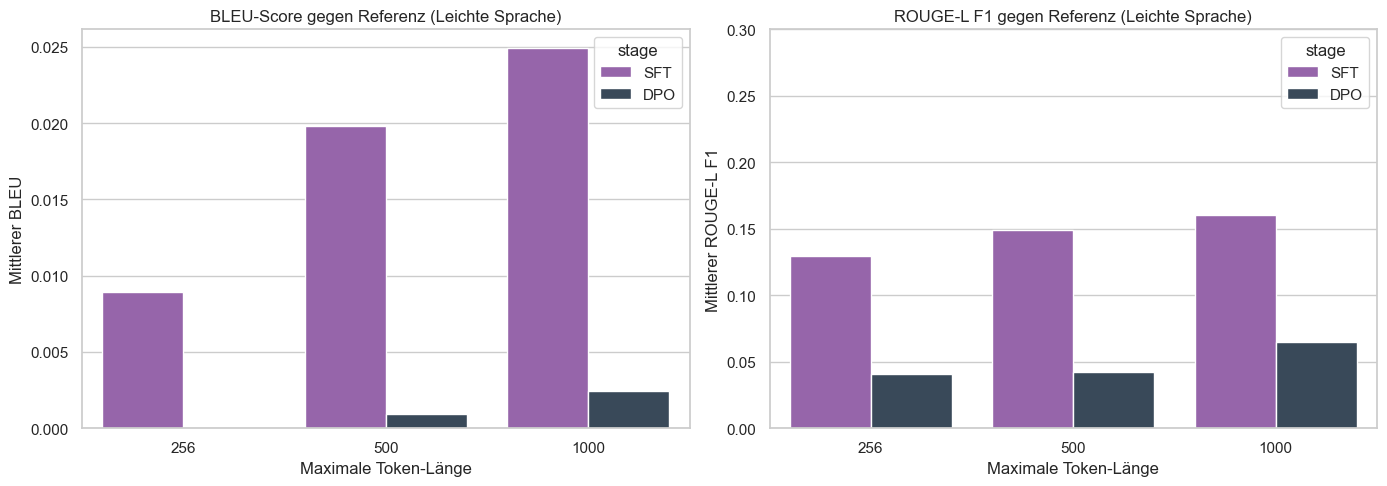

In [5]:
if os.path.exists(SUMMARY_CSV):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. BLEU Score
    sns.barplot(data=df_summary, x='max_len', y='bleu_mean', hue='stage', ax=axes[0], palette=['#9B59B6', '#34495E'])
    axes[0].set_title("BLEU-Score gegen Referenz (Leichte Sprache)")
    axes[0].set_xlabel("Maximale Token-Länge")
    axes[0].set_ylabel("Mittlerer BLEU")

    # 2. ROUGE-L F1
    sns.barplot(data=df_summary, x='max_len', y='rougeL_f1_mean', hue='stage', ax=axes[1], palette=['#9B59B6', '#34495E'])
    axes[1].set_title("ROUGE-L F1 gegen Referenz (Leichte Sprache)")
    axes[1].set_xlabel("Maximale Token-Länge")
    axes[1].set_ylabel("Mittlerer ROUGE-L F1")
    axes[1].set_ylim(0, 0.30)

    plt.tight_layout()
    plt.show()

## 5. Stratifizierte Analyse nach Textlängen-Klassen der Inputs
Untersuchung, wie sich Modelle auf kurzen (< 200 Tokens), mittleren (200-450 Tokens) und langen (> 450 Tokens) Artikeln verhalten.

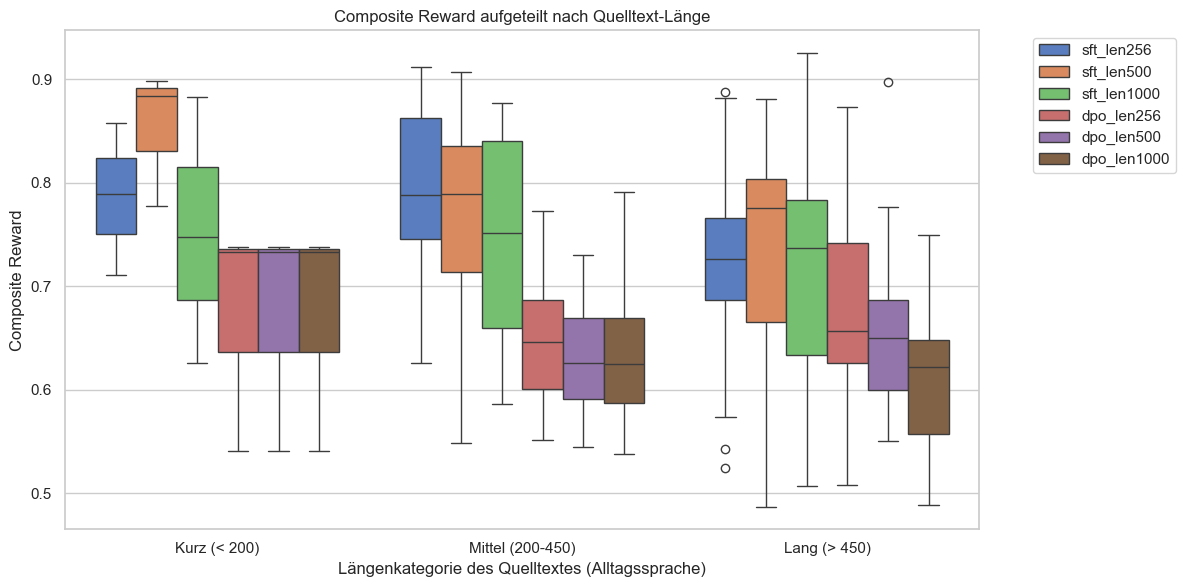

In [6]:
if os.path.exists(DETAILS_CSV):
    df_details = pd.read_csv(DETAILS_CSV)
    
    def categorize_length(src_tokens):
        if src_tokens < 200:
            return 'Kurz (< 200)'
        elif src_tokens <= 450:
            return 'Mittel (200-450)'
        else:
            return 'Lang (> 450)'
            
    df_details['length_cat'] = df_details['src_tokens'].apply(categorize_length)
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_details, x='length_cat', y='composite_reward', hue='model',
                order=['Kurz (< 200)', 'Mittel (200-450)', 'Lang (> 450)'])
    plt.title("Composite Reward aufgeteilt nach Quelltext-Länge")
    plt.xlabel("Längenkategorie des Quelltextes (Alltagssprache)")
    plt.ylabel("Composite Reward")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Detailergebnisse nicht gefunden.")

## 6. Qualitativer Text-Vergleich (Side-by-Side)
Vergleich ausgewählter vereinfachter Übersetzungen zwischen 256, 500 und 1000 Token-Modellen.

In [7]:
if os.path.exists(DETAILS_CSV):
    df_details = pd.read_csv(DETAILS_CSV)
    unique_texts = df_details['as_text'].unique()
    
    if len(unique_texts) > 0:
        sample_text = unique_texts[0]
        sub_df = df_details[df_details['as_text'] == sample_text]
        
        print("=== ORIGINALER QUELLTEXT (Alltagssprache) ===")
        print(sample_text[:400] + ("..." if len(sample_text) > 400 else ""))
        print("\n=== REFERENZTEXT (Leichte Sprache) ===")
        print(sub_df['ls_ref_text'].iloc[0][:400] + "...")
        print("\n" + "="*60)
        
        for _, row in sub_df.iterrows():
            print(f"\nModell: {row['model']} | Tokens: {row['gen_tokens']} | Reward: {row['composite_reward']:.4f} | Truncated: {row['is_truncated']}")
            print(f"Übersetzung: {str(row['generated_text'])[:350]}...")
else:
    print("Keine Detailergebnisse zur qualitativen Ansicht verfügbar.")

=== ORIGINALER QUELLTEXT (Alltagssprache) ===
Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dringend fordern. Der Lohn der Mitarbeiter*innen mit Werkstattvertrag ist bei einem 6 – 8 Stunden Arbeitstag weit davon entfernt, auf dieser Basis ein selb...

=== REFERENZTEXT (Leichte Sprache) ===
Positionspapier: Bildung und Teilhabe am Arbeitsleben für Alle in einem inklusiven Arbeitsmarkt. Positionspapier bedeutet: Mehrere Gruppen haben diesen Text geschrieben. Sie haben Ihre Meinung aufgeschrieben. Und sie haben Ihre Ideen aufgeschrieben. Diese Meinungen und Ideen heißen auch: Positionen zum Thema. Die Positionen sollen viele Menschen lesen. Worum geht es in diesem Text? Alle Menschen h...


Modell: sft_len256 | Tokens: 204 | Reward: 0.8752 | Truncated: False
Übersetzung: Was ist Arbeit zweiter